In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

In [2]:
landsat_stat_paths = ["LT05_Metadata_Export.csv", "LE07_Metadata_Export.csv", "LC08_Metadata_Export.csv"]

dtype_mappping = dict(WRS_PATH='int32', WRS_ROW='int32', CLOUD_COVER='int32')


landsat_df = pd.concat([pd.read_csv(p).assign(source=p.split('_')[0]).astype(dtype_mappping) for p in landsat_stat_paths])
landsat_df

# convert datetime
landsat_df['date'] = pd.to_datetime(landsat_df['date'])

# add explict year and month for stats
landsat_df["month"] = landsat_df['date'].dt.month
landsat_df["year"] = landsat_df['date'].dt.year


# add tile id for 
landsat_df['tile_id'] = "P" + landsat_df['WRS_PATH'].astype(str) + '-' + "R" + landsat_df['WRS_ROW'].astype(int).astype(str)

# add inverse cloudless for stats

landsat_df["CLOUDLESS"] = 100 - landsat_df['CLOUD_COVER']
landsat_df

,system_index,date,WRS_PATH,WRS_ROW,CLOUD_COVER,IMAGE_QUALITY,source,month,year,tile_id,CLOUDLESS
0,LT05_191024_20000317,2000-03-17,191,24,55,9.0,LT05,3,2000,P191-R24,45
1,LT05_191024_20000504,2000-05-04,191,24,33,9.0,LT05,5,2000,P191-R24,67
2,LT05_191024_20000605,2000-06-05,191,24,31,9.0,LT05,6,2000,P191-R24,69
3,LT05_191024_20000621,2000-06-21,191,24,1,9.0,LT05,6,2000,P191-R24,99
4,LT05_191024_20000909,2000-09-09,191,24,55,9.0,LT05,9,2000,P191-R24,45
...,...,...,...,...,...,...,...,...,...,...,...
3249,LC08_198025_20170925,2017-09-25,198,25,18,NaN,LC08,9,2017,P198-R25,82
3250,LC08_198025_20171027,2017-10-27,198,25,35,NaN,LC08,10,2017,P198-R25,65
3251,LC08_198025_20171112,2017-11-12,198,25,81,NaN,LC08,11,2017,P198-R25,19
3252,LC08_198025_20171128,2017-11-28,198,25,36,NaN,LC08,11,2017,P198-R25,64


In [3]:
# load the relevant tiles

relevant_tiles = gpd.read_file("relevant_tiles.gpkg").astype({k: dtype_mappping[k] for k in dtype_mappping if k != "CLOUD_COVER"})
relevant_tiles

,WRS_PATH,WRS_ROW,remaining_area,geometry
0,195,27,0.244297,MULTIPOLYGON Z (((1058648.357 6114844.043 7000...
1,194,27,0.425767,MULTIPOLYGON Z (((1230636.971 6114844.043 7000...
2,193,27,0.464225,MULTIPOLYGON Z (((1402625.584 6114844.043 7000...
3,192,27,0.263979,MULTIPOLYGON Z (((1441934.958 6143902.698 7000...
4,196,26,0.328061,"MULTIPOLYGON Z (((954787.273 6352934.763 7000,..."
5,195,26,0.827768,MULTIPOLYGON Z (((1126775.886 6352934.763 7000...
6,194,26,1.000000,MULTIPOLYGON Z (((1298764.499 6352934.763 7000...
7,193,26,0.976172,MULTIPOLYGON Z (((1398333.958 6369279.357 7000...
8,192,26,0.512568,MULTIPOLYGON Z (((1386543.758 6410757.198 7000...
9,197,25,0.413723,"MULTIPOLYGON Z (((854377.092 6597448.438 7000,..."


In [4]:
relevant_tiles[relevant_tiles['WRS_PATH'] ==194]

,WRS_PATH,WRS_ROW,remaining_area,geometry
1,194,27,0.425767,MULTIPOLYGON Z (((1230636.971 6114844.043 7000...
6,194,26,1.000000,MULTIPOLYGON Z (((1298764.499 6352934.763 7000...
12,194,25,1.000000,MULTIPOLYGON Z (((1370342.932 6597448.438 7000...
18,194,24,1.000000,MULTIPOLYGON Z (((1445817.546 6848911.013 7000...
24,194,23,0.990597,MULTIPOLYGON Z (((1278191.915 7169242.323 7000...
29,194,22,0.329961,MULTIPOLYGON Z (((1546065.494 7171981.378 7000...


In [5]:
relevant_tiles["WRS_PATH"].dtype

dtype('int32')

In [6]:
landsat_df["WRS_PATH"].dtype

dtype('int32')

In [6]:
relevant_landsat_df = landsat_df.merge(relevant_tiles, how='inner', on=['WRS_PATH', 'WRS_ROW'])
relevant_landsat_df

,system_index,date,WRS_PATH,WRS_ROW,CLOUD_COVER,IMAGE_QUALITY,source,month,year,tile_id,CLOUDLESS,remaining_area,geometry
0,LT05_192023_20000527,2000-05-27,192,23,43,9.0,LT05,5,2000,P192-R23,57,0.261510,"MULTIPOLYGON Z (((1472088.946 6893053.46 7000,..."
1,LT05_192023_20000628,2000-06-28,192,23,82,9.0,LT05,6,2000,P192-R23,18,0.261510,"MULTIPOLYGON Z (((1472088.946 6893053.46 7000,..."
2,LT05_192023_20000831,2000-08-31,192,23,67,9.0,LT05,8,2000,P192-R23,33,0.261510,"MULTIPOLYGON Z (((1472088.946 6893053.46 7000,..."
3,LT05_192023_20001103,2000-11-03,192,23,97,9.0,LT05,11,2000,P192-R23,3,0.261510,"MULTIPOLYGON Z (((1472088.946 6893053.46 7000,..."
4,LT05_192023_20001119,2000-11-19,192,23,6,9.0,LT05,11,2000,P192-R23,94,0.261510,"MULTIPOLYGON Z (((1472088.946 6893053.46 7000,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11490,LC08_197025_20170902,2017-09-02,197,25,44,NaN,LC08,9,2017,P197-R25,56,0.413723,"MULTIPOLYGON Z (((854377.092 6597448.438 7000,..."
11491,LC08_197025_20171004,2017-10-04,197,25,100,NaN,LC08,10,2017,P197-R25,0,0.413723,"MULTIPOLYGON Z (((854377.092 6597448.438 7000,..."
11492,LC08_197025_20171020,2017-10-20,197,25,43,NaN,LC08,10,2017,P197-R25,57,0.413723,"MULTIPOLYGON Z (((854377.092 6597448.438 7000,..."
11493,LC08_197025_20171105,2017-11-05,197,25,65,NaN,LC08,11,2017,P197-R25,35,0.413723,"MULTIPOLYGON Z (((854377.092 6597448.438 7000,..."


In [4]:
import seaborn as sns
import matplotlib.dates as mdates

In [8]:
# 1. Set the high-level theme
sns.set_theme(style="whitegrid", font="sans-serif", rc={'figure.figsize':(25,10)})

# 2. Configure specific aesthetics
sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1.5})

# 3. Choose a color palette (Set2 is great for distinct tile IDs)
palette = sns.color_palette("Set2")

<Axes: xlabel='CLOUD_COVER', ylabel='Percent'>

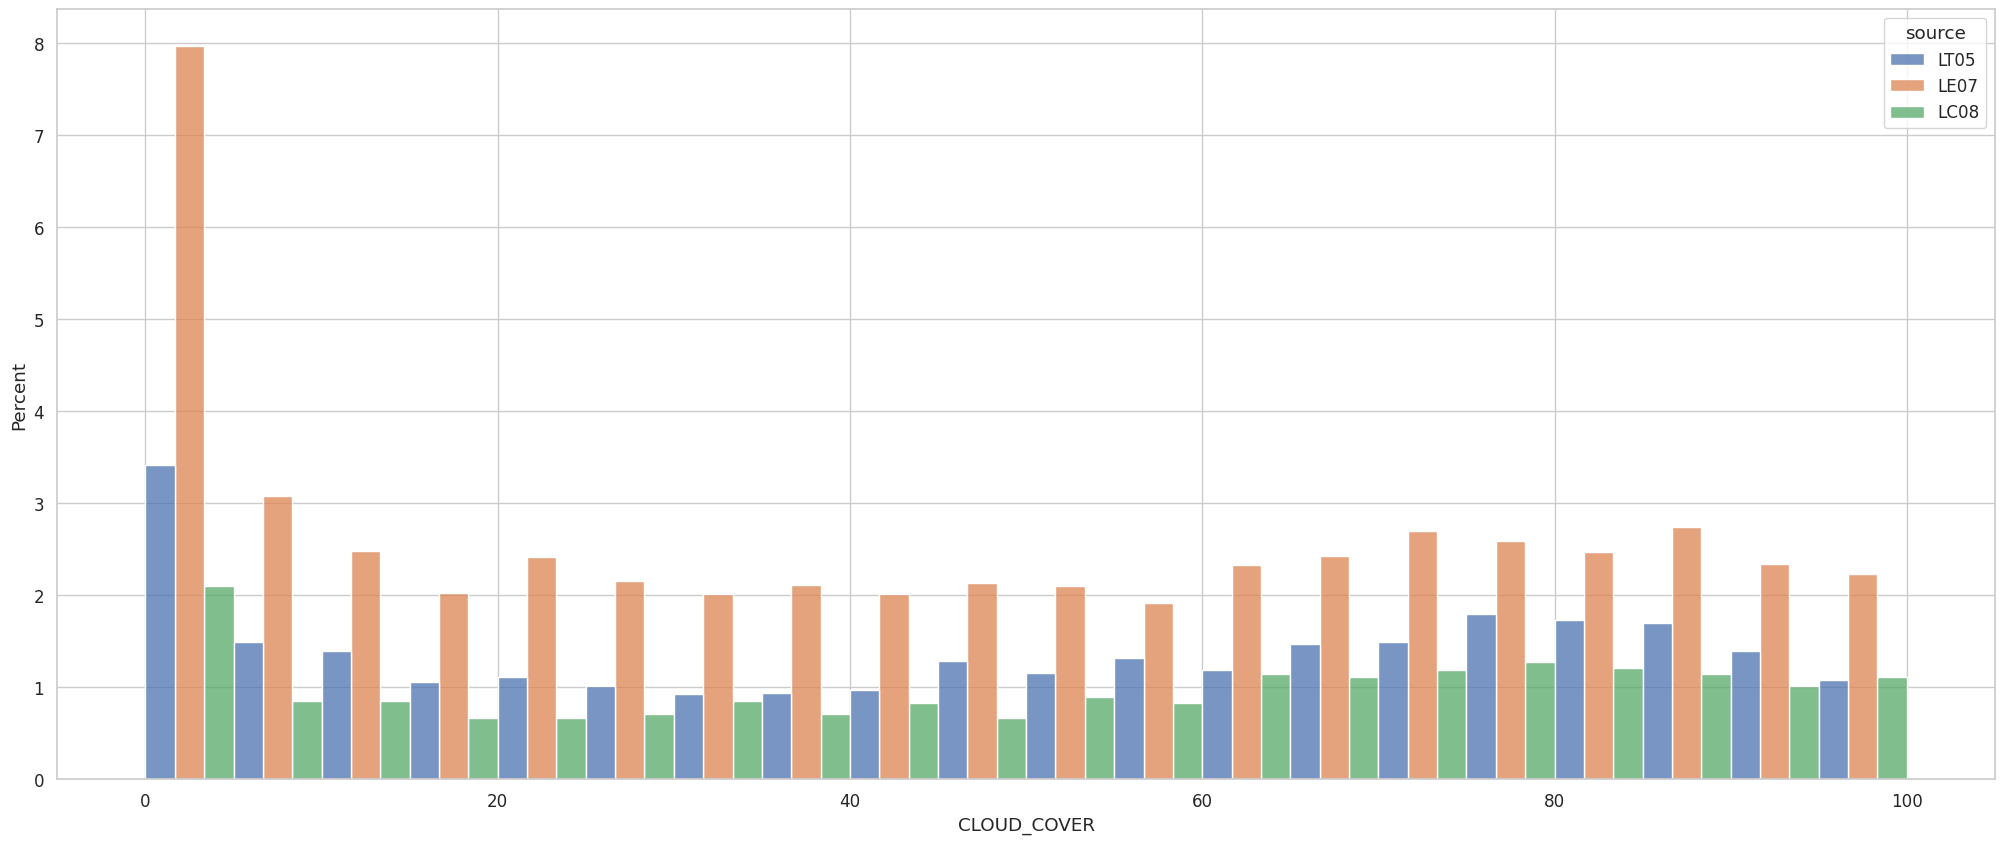

In [9]:
sns.histplot(data=relevant_landsat_df, x='CLOUD_COVER', stat='percent', hue='source', multiple='dodge')

In [11]:
custom_palette = sns.blend_palette(["#d3d3d3", "#95a5a6", "#f1c40f"], as_cmap=True)

In [15]:
years = pd.date_range(relevant_landsat_df['date'].min(), relevant_landsat_df['date'].max(), freq='YS').year
years

Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017],
      dtype='int32')

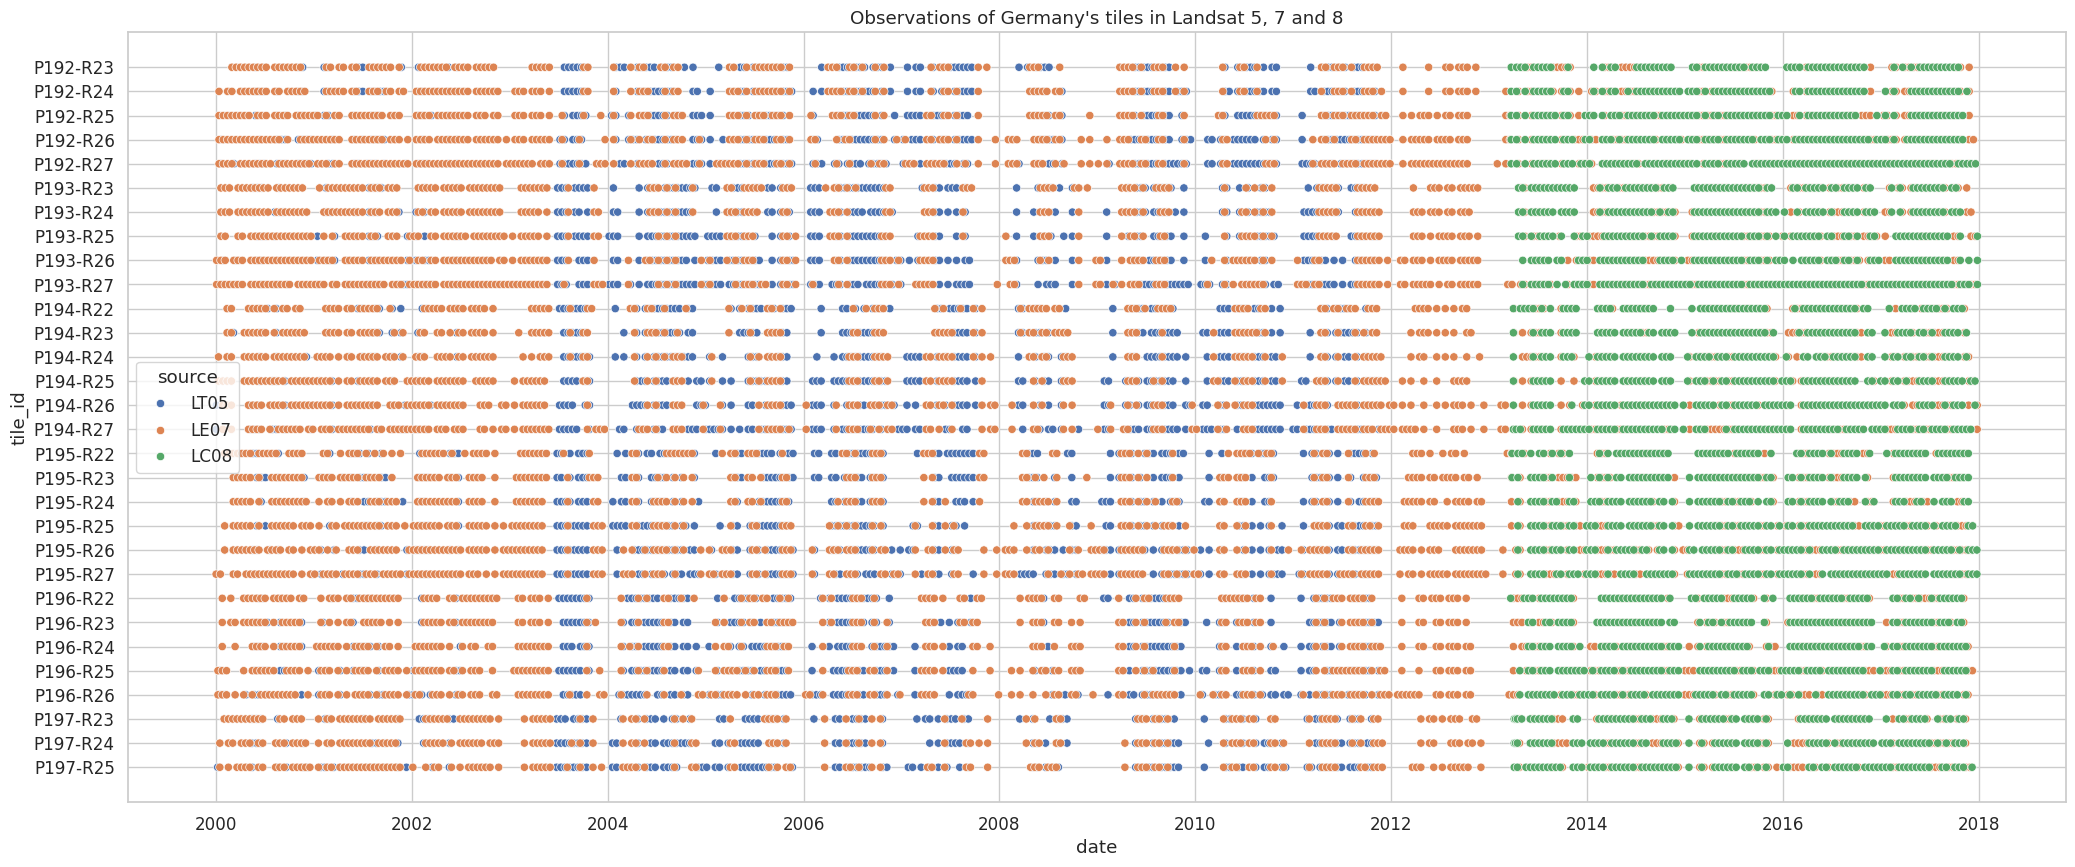

In [17]:

ax = sns.scatterplot(relevant_landsat_df, x='date', y='tile_id', hue="source")

# years = pd.date_range(relevant_landsat_df['date'].min(), relevant_landsat_df['date'].max(), freq='YS').year
# plt.xticks(years)

ax.set_title("Observations of Germany's tiles in Landsat 5, 7 and 8")
plt.show()

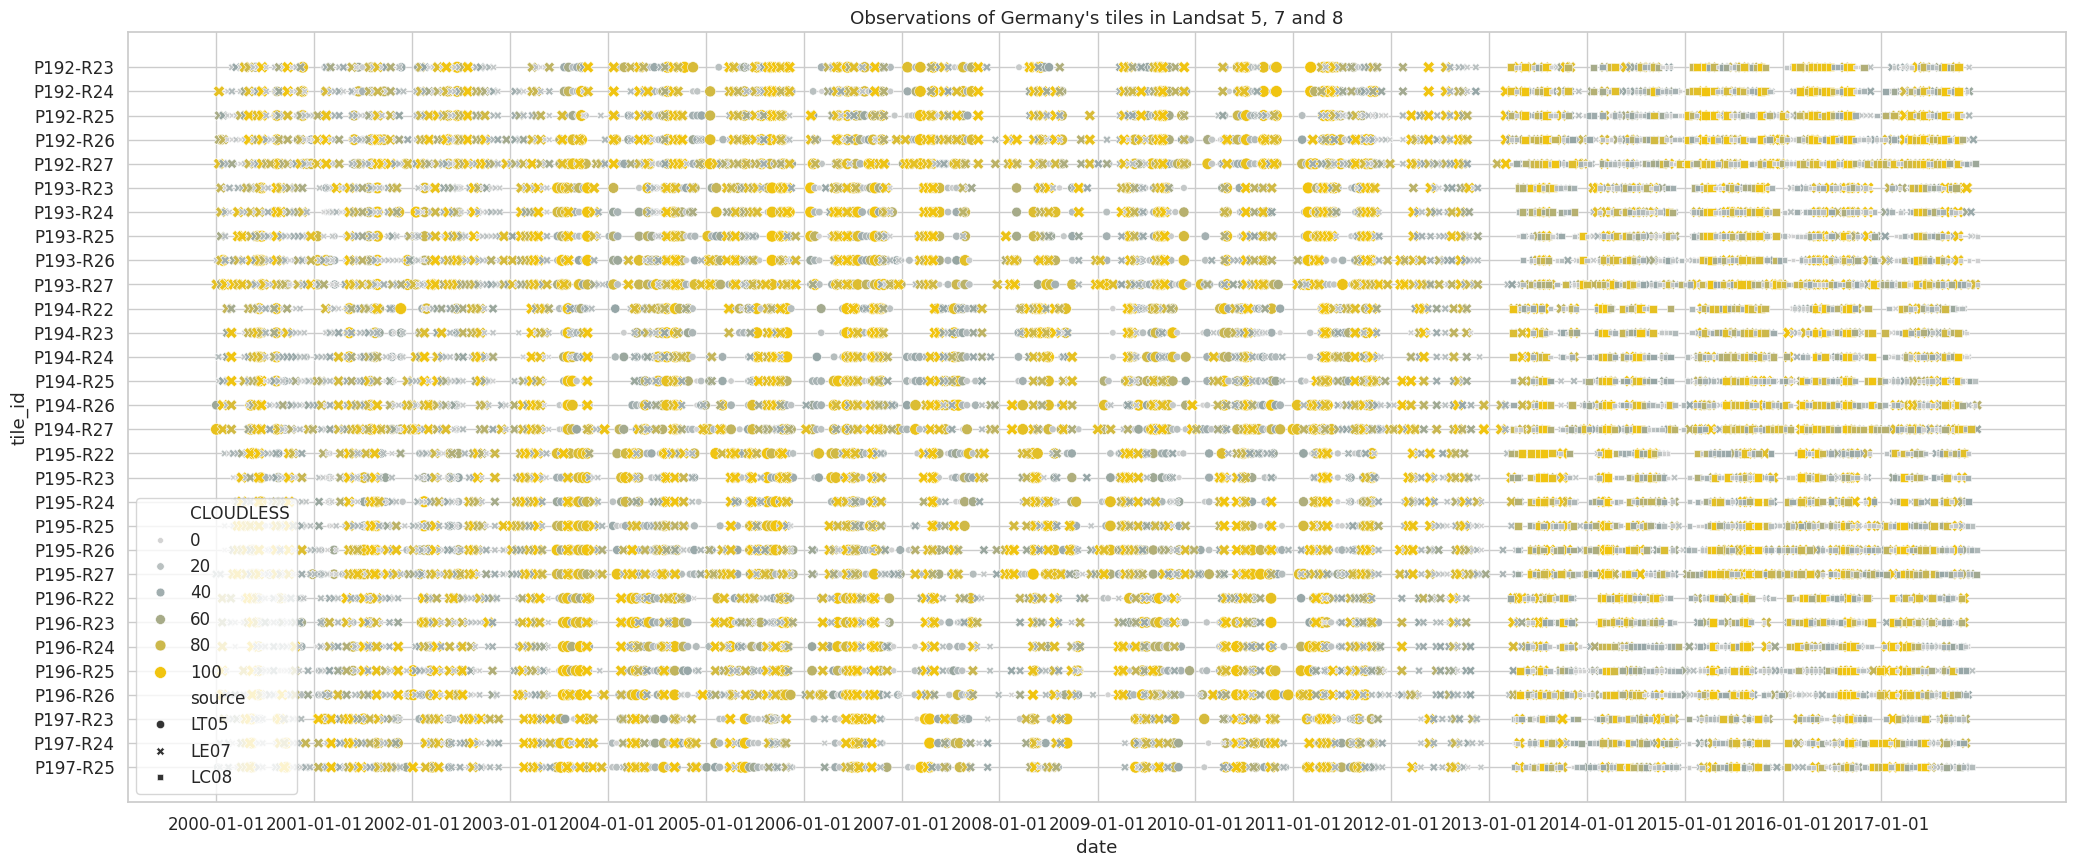

In [12]:
ax = sns.scatterplot(relevant_landsat_df, x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style="source", palette=custom_palette)

years = pd.date_range(relevant_landsat_df['date'].min(), relevant_landsat_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Observations of Germany's tiles in Landsat 5, 7 and 8")
plt.show()

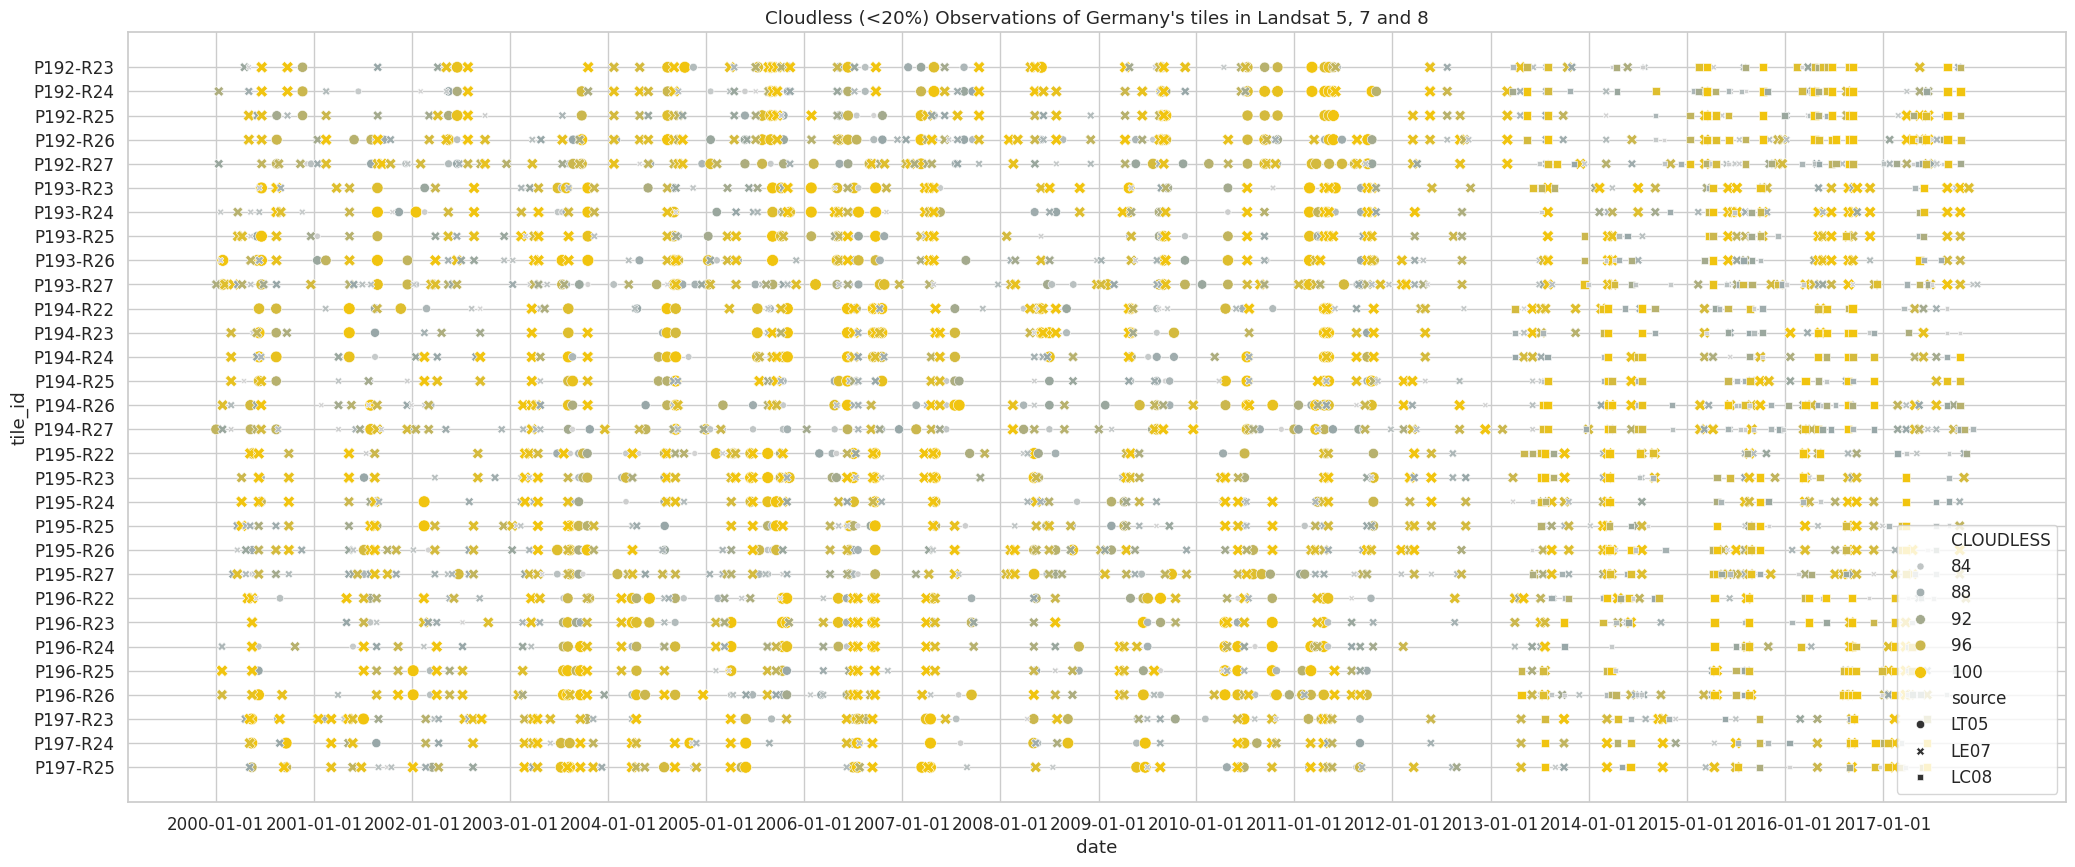

In [13]:
ax = sns.scatterplot(relevant_landsat_df[relevant_landsat_df['CLOUD_COVER'] < 20], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style="source", palette=custom_palette)

years = pd.date_range(relevant_landsat_df['date'].min(), relevant_landsat_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless (<20%) Observations of Germany's tiles in Landsat 5, 7 and 8")
plt.show()

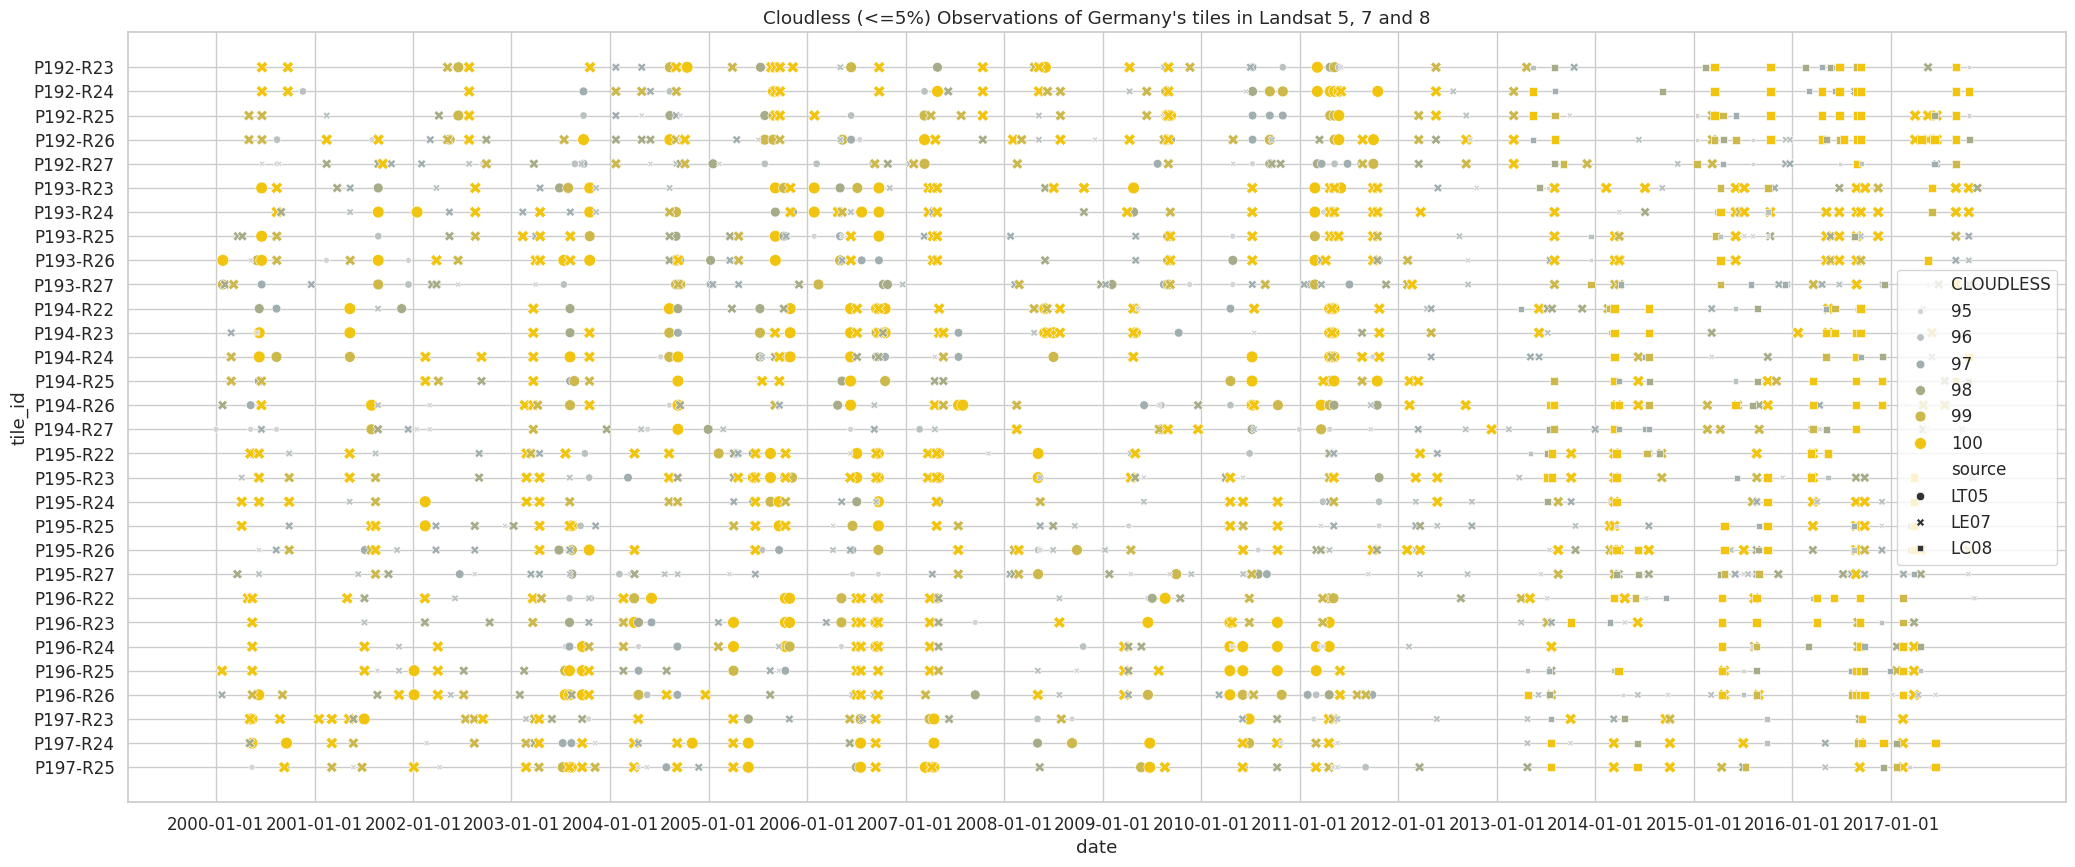

In [14]:
ax = sns.scatterplot(relevant_landsat_df[relevant_landsat_df['CLOUD_COVER'] <= 5], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style="source", palette=custom_palette)

years = pd.date_range(relevant_landsat_df['date'].min(), relevant_landsat_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless (<=5%) Observations of Germany's tiles in Landsat 5, 7 and 8")
plt.show()

In [16]:
def filter_out_faulty_landsat7(df, src='LE07'):

    filtered_df = df[(df['source'] != src) | (df['date'] < pd.to_datetime('2003-05-31'))]

    return filtered_df

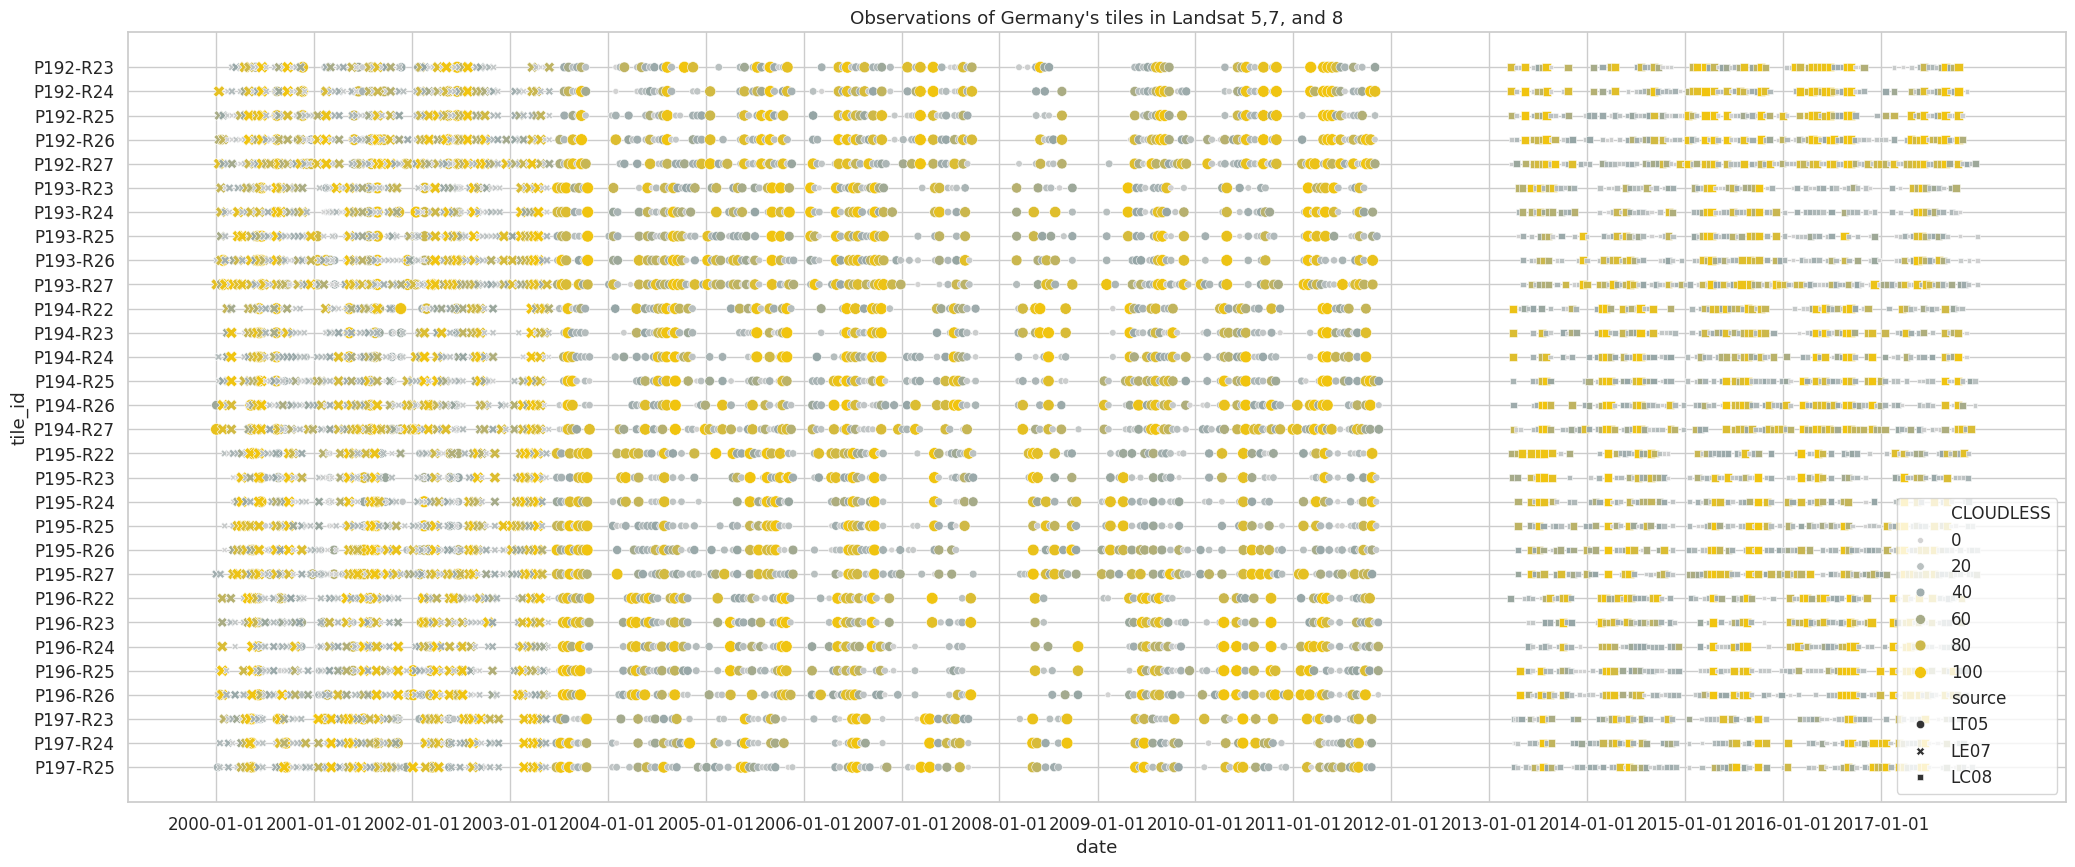

In [17]:
l5_l8_only = filter_out_faulty_landsat7(relevant_landsat_df)

ax = sns.scatterplot(l5_l8_only, x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style='source', palette=custom_palette)

years = pd.date_range(l5_l8_only['date'].min(), l5_l8_only['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Observations of Germany's tiles in Landsat 5,7, and 8")
plt.show()

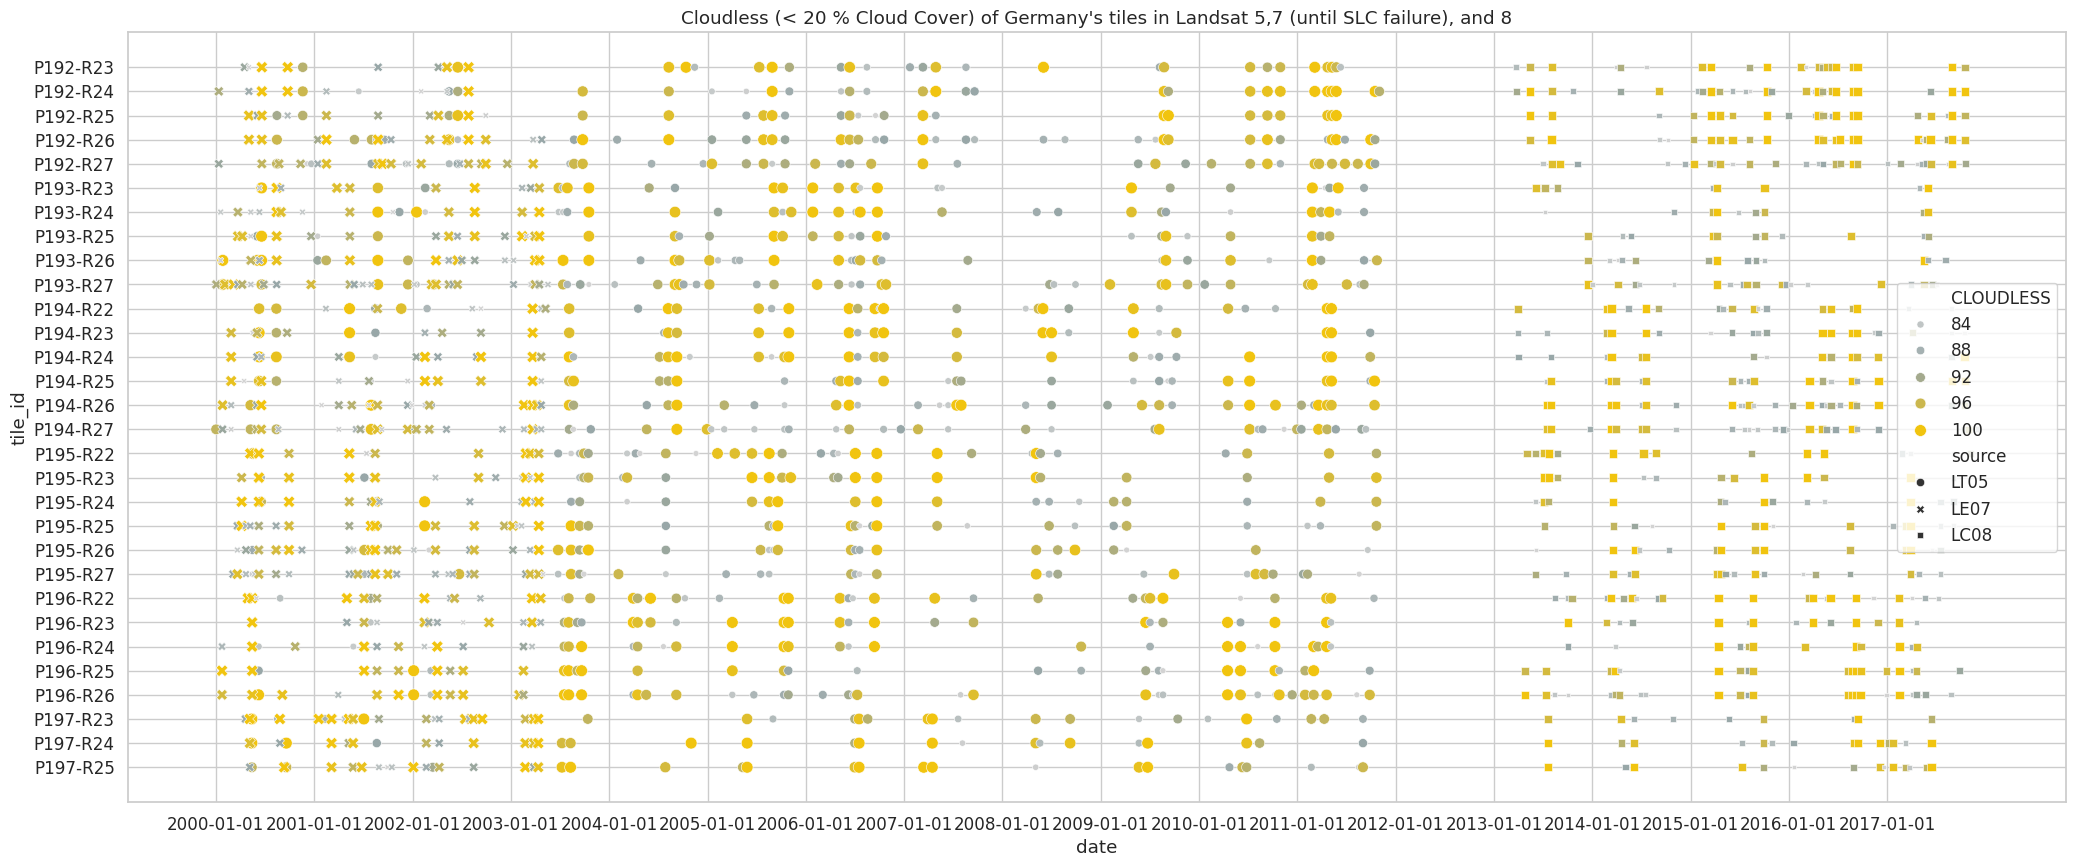

In [21]:
ax = sns.scatterplot(l5_l8_only[l5_l8_only['CLOUD_COVER'] < 20], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style='source', palette=custom_palette)

years = pd.date_range(l5_l8_only['date'].min(), l5_l8_only['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless (< 20 % Cloud Cover) of Germany's tiles in Landsat 5,7 (until SLC failure), and 8")
plt.show()

In [ ]:
def get_covered_years(date, left_pad=2, right_pad=2):
    """
    Returns a list of years that this date contributes to,
    considering padding of months left and right.
    """
    year = date.year
    month = date.month
    
    years = [year]  # always counts for its own year
    
    # check if it falls in left padding of the next year
    if month > 12 - right_pad:
        years.append(year + 1)
        
    # check if it falls in right padding of the previous year
    if month <= left_pad:
        years.append(year - 1)
    
    return years

In [72]:
def compute_day_of_year_for_padded_year(row, left_pad=2, right_pad=2):
    """
    Compute day_of_year relative to the covered year.
    """
    original_doy = row['date'].timetuple().tm_yday
    month = row['date'].month
    covered_year = row['covered_years']
    actual_year = row['date'].year
    
    # If this date contributes to previous year (early months)
    if covered_year == actual_year - 1 and month <= left_pad:
        # Treat as late in previous year: day_of_year near 365
        # Approximate: shift by 365 - number of days left in the year
        return original_doy - 1 + 365  # simple way
    
    # If this date contributes to next year (late months)
    elif covered_year == actual_year + 1 and month > 12 - right_pad:
        # Treat as early in next year: day_of_year near 1
        # Shift to start of next year
        return original_doy - 365  # negative values will sort at start
    
    else:
        # normal year
        return original_doy

In [59]:
df_expanded = relevant_landsat_df[relevant_landsat_df['CLOUD_COVER'] < 20].copy()

# apply the function and explode the list
df_expanded['covered_years'] = df_expanded['date'].apply(get_covered_years)
df_expanded = df_expanded.explode('covered_years')
df_expanded['covered_years'] = df_expanded['covered_years'].astype(int)

In [73]:
df_expanded['day_of_year'] = df_expanded.apply(compute_day_of_year_for_padded_year, axis=1)

# number of observations
obs_count = df_expanded.groupby(['tile_id', 'covered_years']).size().reset_index(name='obs_count')

# spread of observations
spread = df_expanded.groupby(['tile_id', 'covered_years'])['day_of_year'].std().reset_index(name='spread')

# merge metrics
coverage = obs_count.merge(spread, on=['tile_id', 'covered_years'])
# normalize spread
coverage['coverage_score'] = coverage['obs_count'] * (coverage['spread'].fillna(0) / 365)

In [74]:
coverage

,tile_id,covered_years,obs_count,spread,coverage_score
0,P192-R23,2000,5,93.569226,1.281770
1,P192-R23,2001,2,197.282792,1.081002
2,P192-R23,2002,4,48.607270,0.532682
3,P192-R23,2003,2,67.175144,0.368083
4,P192-R23,2004,6,111.627953,1.834980
...,...,...,...,...,...
552,P197-R25,2013,4,69.243532,0.758833
553,P197-R25,2014,4,87.878704,0.963054
554,P197-R25,2015,6,113.652834,1.868266
555,P197-R25,2016,8,136.313714,2.987698


<Axes: xlabel='covered_years', ylabel='tile_id'>

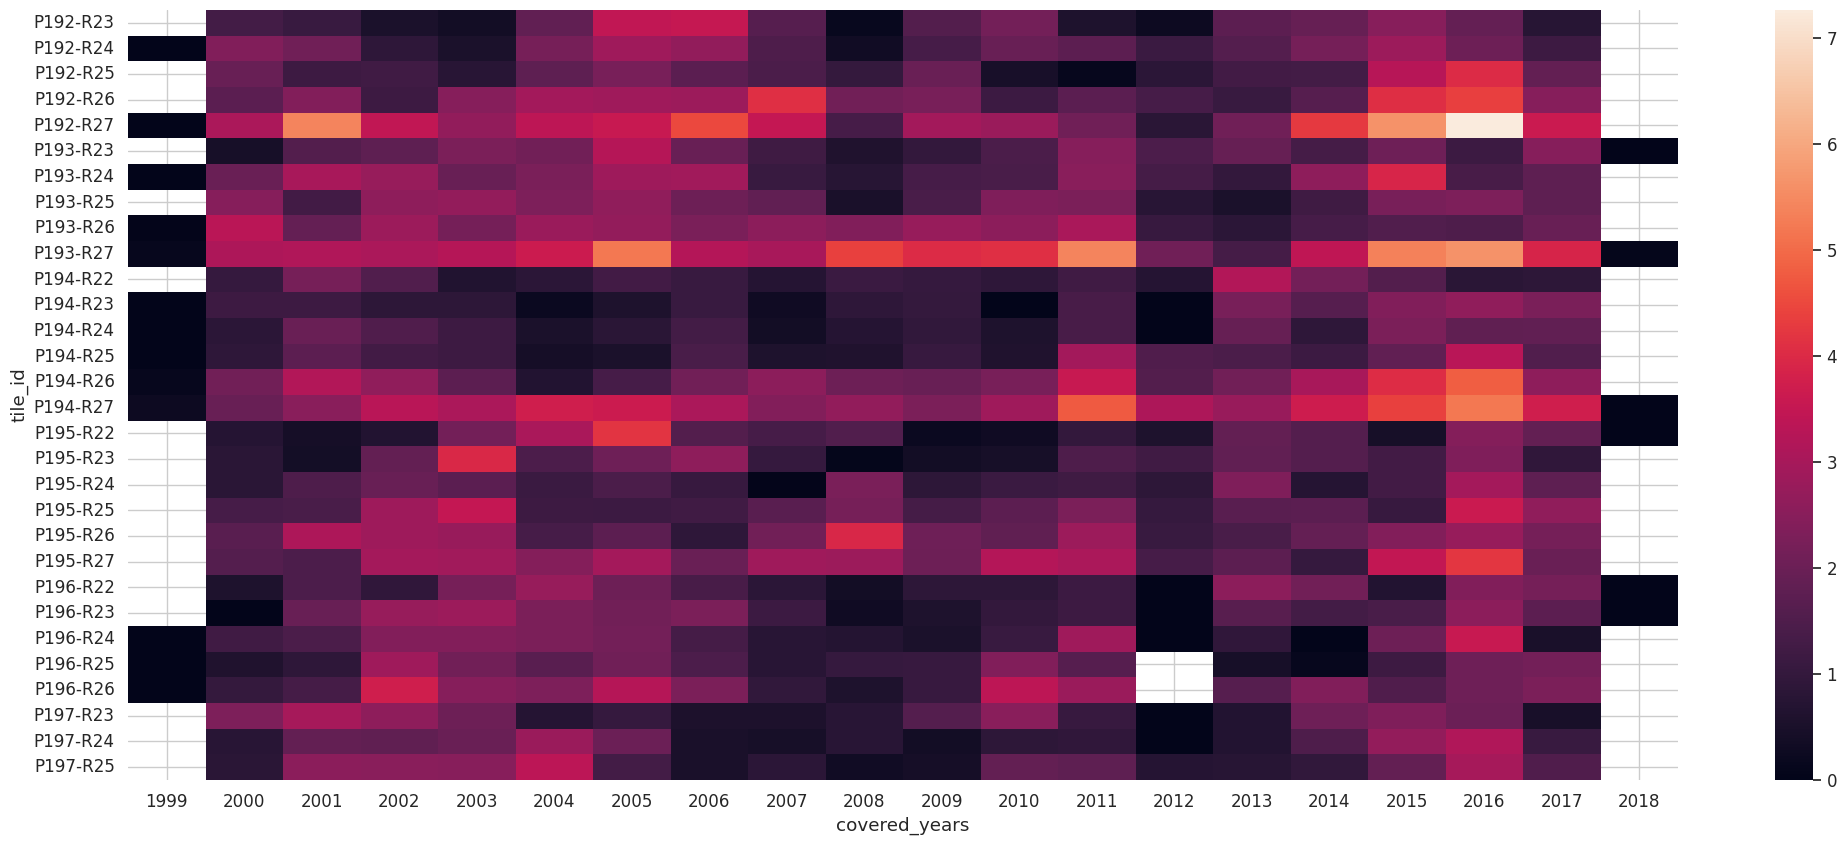

In [ ]:
sns.heatmap(coverage[coverage['covered']].pivot(index="tile_id", columns="covered_years", values="coverage_score"))

In [16]:
l5_df['source'] = 'landsat5'
l7_df['source'] = 'landsat7'

landsat_df = pd.concat([l5_df, l7_df])
landsat_df

,system_index,date,WRS_PATH,WRS_ROW,CLOUD_COVER,IMAGE_QUALITY,tile_id,CLOUDLESS,month,year,source
0,LT05_191024_20000317,2000-03-17,191.0,24.0,55.0,9.0,191-24,45.0,3,2000,landsat5
1,LT05_191024_20000504,2000-05-04,191.0,24.0,33.0,9.0,191-24,67.0,5,2000,landsat5
2,LT05_191024_20000605,2000-06-05,191.0,24.0,31.0,9.0,191-24,69.0,6,2000,landsat5
3,LT05_191024_20000621,2000-06-21,191.0,24.0,1.0,9.0,191-24,99.0,6,2000,landsat5
4,LT05_191024_20000909,2000-09-09,191.0,24.0,55.0,9.0,191-24,45.0,9,2000,landsat5
...,...,...,...,...,...,...,...,...,...,...,...
5366,LE07_198025_20120903,2012-09-03,198.0,25.0,88.0,9.0,198-25,12.0,9,2012,landsat7
5367,LE07_198025_20120919,2012-09-19,198.0,25.0,36.0,9.0,198-25,64.0,9,2012,landsat7
5368,LE07_198025_20121021,2012-10-21,198.0,25.0,50.0,9.0,198-25,50.0,10,2012,landsat7
5369,LE07_198025_20121122,2012-11-22,198.0,25.0,36.0,9.0,198-25,64.0,11,2012,landsat7


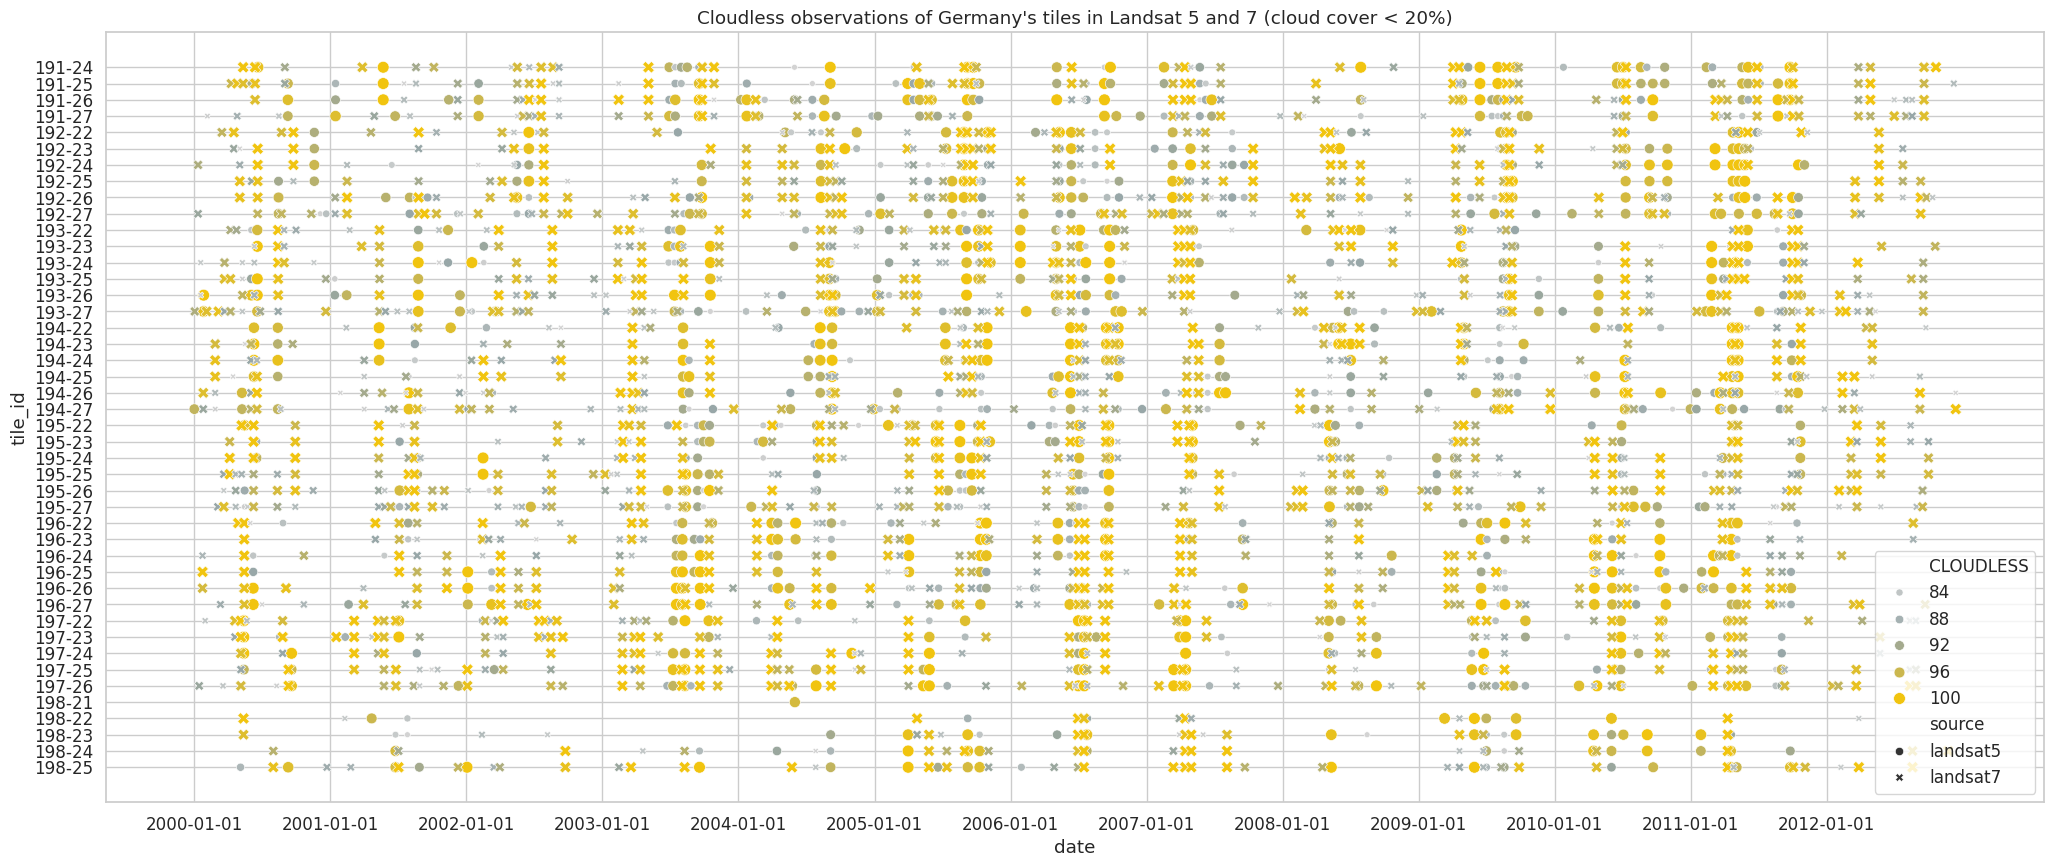

In [16]:
ax = sns.scatterplot(landsat_df[landsat_df["CLOUD_COVER"] < 20], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style='source', palette=custom_palette)

years = pd.date_range(landsat_df['date'].min(), landsat_df['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Cloudless observations of Germany's tiles in Landsat 5 and 7 (cloud cover < 20%)")
plt.show()

In [25]:
def filter_df_relevant(df, df_relevant):

    idx = pd.MultiIndex.from_frame(df_relevant[['WRS_PATH','WRS_ROW']].astype('float'))

    df_filtered = df[
        pd.MultiIndex.from_arrays([df.WRS_PATH, df.WRS_ROW]).isin(idx)
    ]

    return df_filtered


In [26]:
landsat_df_relevant = filter_df_relevant(landsat_df, relevant_gdf)
landsat_df_relevant

,system_index,date,WRS_PATH,WRS_ROW,CLOUD_COVER,IMAGE_QUALITY,tile_id,CLOUDLESS,month,year,source
591,LT05_192023_20000527,2000-05-27,192.0,23.0,43.0,9.0,192-23,57.0,5,2000,landsat5
592,LT05_192023_20000628,2000-06-28,192.0,23.0,82.0,9.0,192-23,18.0,6,2000,landsat5
593,LT05_192023_20000831,2000-08-31,192.0,23.0,67.0,9.0,192-23,33.0,8,2000,landsat5
594,LT05_192023_20001103,2000-11-03,192.0,23.0,97.0,9.0,192-23,3.0,11,2000,landsat5
595,LT05_192023_20001119,2000-11-19,192.0,23.0,6.0,9.0,192-23,94.0,11,2000,landsat5
...,...,...,...,...,...,...,...,...,...,...,...
4897,LE07_197025_20120827,2012-08-27,197.0,25.0,8.0,9.0,197-25,92.0,8,2012,landsat7
4898,LE07_197025_20120912,2012-09-12,197.0,25.0,87.0,9.0,197-25,13.0,9,2012,landsat7
4899,LE07_197025_20120928,2012-09-28,197.0,25.0,68.0,9.0,197-25,32.0,9,2012,landsat7
4900,LE07_197025_20121014,2012-10-14,197.0,25.0,98.0,9.0,197-25,2.0,10,2012,landsat7


In [27]:
threshold = 20
early_months = [2, 3, 4]
late_months = [10, 11]

df_detect = landsat_df_relevant[
    (landsat_df_relevant['CLOUD_COVER'] < threshold)
    & (landsat_df_relevant['month'].isin(early_months + late_months))
]

mask = (
    df_detect.groupby(['year', 'tile_id'])['month']
    .agg(lambda m: any(m.isin(early_months)) and any(m.isin(late_months)))
)

valid_groups = mask[mask].index  # MultiIndex of (year, tile_id)

# 3) Filter to only valid groups
df_full = landsat_df_relevant.set_index(['year', 'tile_id']).loc[valid_groups].reset_index()

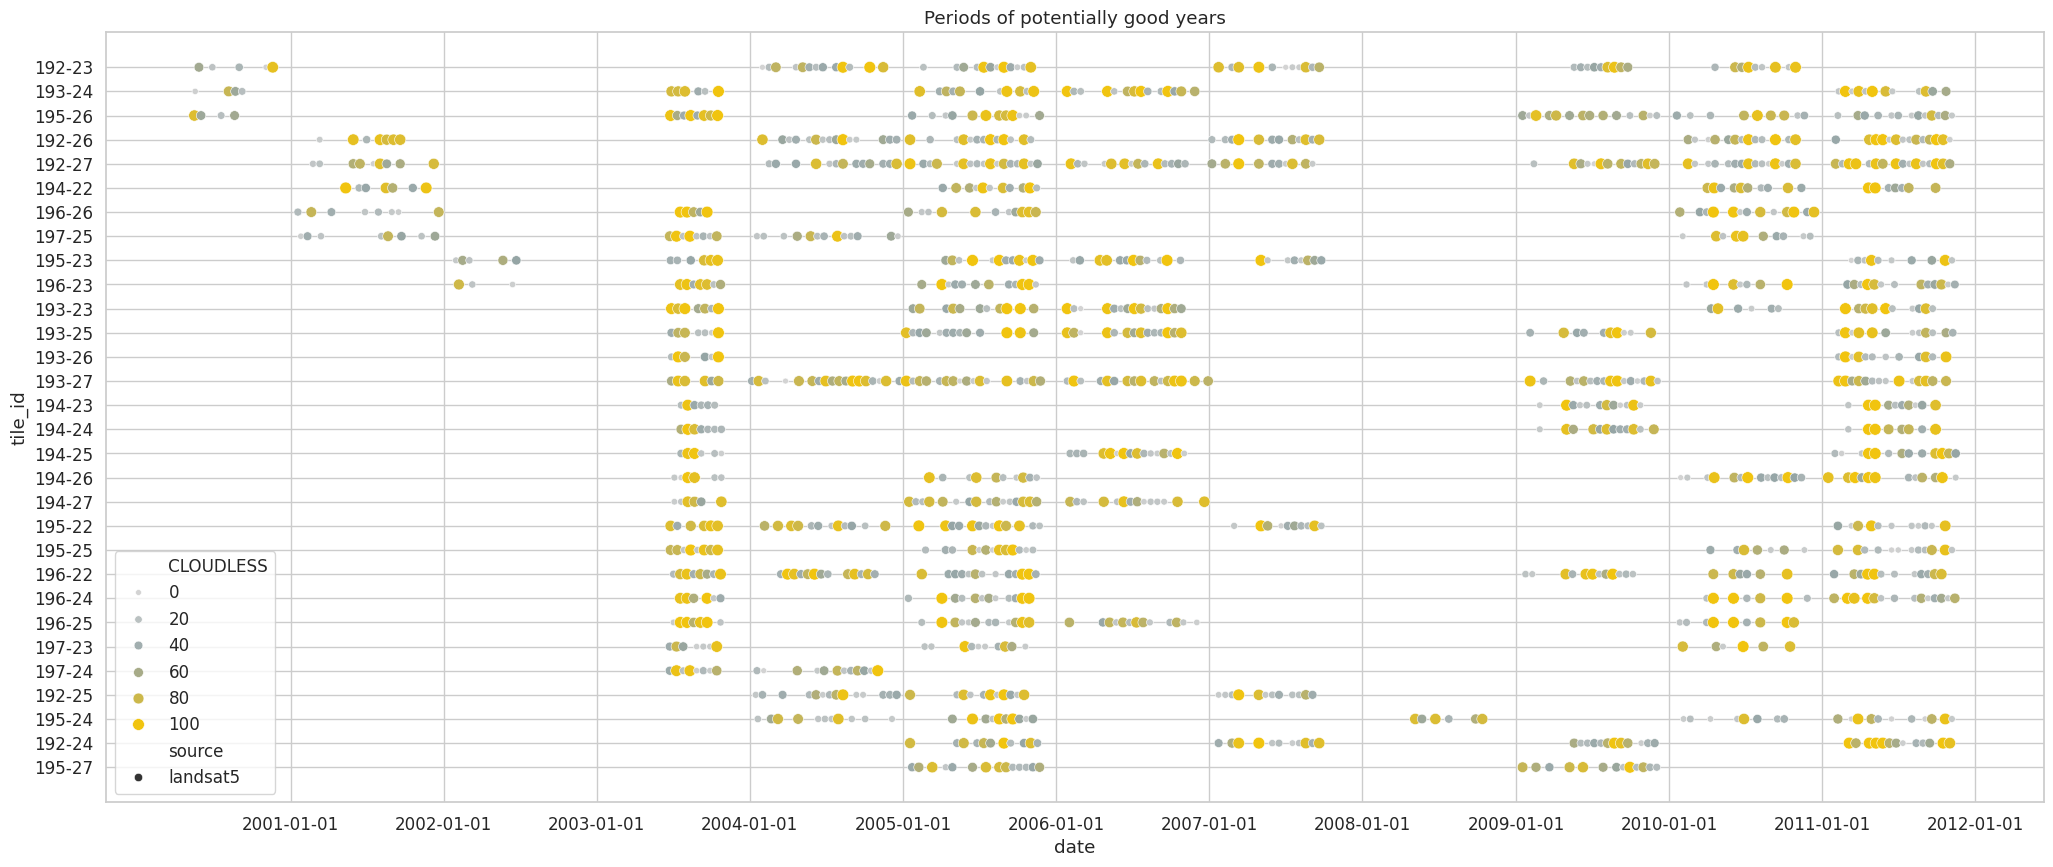

In [29]:
ax = sns.scatterplot(df_full[df_full["source"] == "landsat5"], x='date', y='tile_id', hue="CLOUDLESS", size="CLOUDLESS", style='source', palette=custom_palette)

years = pd.date_range(df_full['date'].min(), df_full['date'].max(), freq='YS')
plt.xticks(years)

ax.set_title("Periods of potentially good years")
plt.show()